In [8]:
import numpy as np
import pandas as pd
import random

from sklearn import ensemble
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, auc, roc_curve

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

import warnings
warnings.filterwarnings("ignore", category=UserWarning) #used to supress the tf version warning. 

import lightgbm as lgb
from lightgbm import LGBMClassifier

In [12]:
# load test data
X_test = pd.read_parquet("../data/model_raw/X_test.parquet")
y_test = pd.read_parquet("../data/model_raw/Y_test.parquet")['depression_severity']
X_test = np.array(X_test)
y_test = np.array(np.where(y_test > 0, 1, 0)) # np array of binary labels

# load models
lr = joblib.load("./model_files/logistic_best_model.pkl")
lgbm = joblib.load("./model_files/lightgbm_best_model.pkl")
rf = joblib.load("./model_files/random_forest_best_model.pkl")
xgb = joblib.load("./model_files/XGB_best_model.pkl")


### baseline guessing based on the distribution of the raw training dataset
y_train_raw = pd.read_parquet("../data/model_raw/Y_train.parquet")
y_train_raw['dep_bin'] = np.where(y_train_raw['depression_severity'] > 0, 1, 0)
y_test = pd.read_parquet("../data/model_raw/Y_test.parquet")['depression_severity']
y_test = np.array(np.where(y_test > 0, 1, 0)) # np array of binary labels

counts = pd.DataFrame(y_train_raw['dep_bin'].value_counts()).reset_index()

guess_0 = counts[counts['dep_bin'] == 0]['count']/counts['count'].sum()
guess_1 = counts[counts['dep_bin'] == 1]['count'] / counts['count'].sum()

ones = np.ones(round(len(y_test) * guess_1).astype(int))
zeros = np.zeros(round(len(y_test) * guess_0).astype(int))

# concatenate 1 and 0 guesses
out = np.concatenate((ones, zeros))
random_df = pd.DataFrame(out, columns=['pred'])

# shuffle 1 and 0 guesses randomly
np.random.seed(12345)
indices = random_df.index.tolist()
shuffled_indices = np.random.permutation(indices)
baseline_preds = random_df.reindex(shuffled_indices).reset_index(drop=True)

# probability of positive class in training data
baseline_prob = guess_1.values[0]

# constant probability predictions
baseline_probs = np.full(len(y_test), baseline_prob)

In [65]:
baseline_preds

,pred
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
...,...
1009,0.0
1010,1.0
1011,0.0
1012,0.0


In [41]:
y_test_pred = xgb.predict(X_test)

classification_report(y_test, y_test_pred, output_dict=True)

{'0': {'precision': 0.8810289389067524,
  'recall': 0.7061855670103093,
  'f1-score': 0.7839771101573677,
  'support': 776.0},
 '1': {'precision': 0.41836734693877553,
  'recall': 0.6890756302521008,
  'f1-score': 0.5206349206349207,
  'support': 238.0},
 'accuracy': 0.7021696252465484,
 'macro avg': {'precision': 0.649698142922764,
  'recall': 0.697630598631205,
  'f1-score': 0.6523060153961442,
  'support': 1014.0},
 'weighted avg': {'precision': 0.7724357841844856,
  'recall': 0.7021696252465484,
  'f1-score': 0.7221670104469708,
  'support': 1014.0}}

In [42]:
fpr, tpr, _ = roc_curve(y_test, y_test_pred)
roc_auc = auc(fpr, tpr)
roc_auc

0.697630598631205

In [84]:
# model probabilities (positive class = 1)
lr_pred = lr.model.predict(X_test).ravel()
lgbm_pred = lgbm.predict_proba(X_test)[:, 1]
rf_pred= rf.predict_proba(X_test)[:, 1]
xgb_pred = xgb.predict_proba(X_test)[:, 1]

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [85]:
# compute ROC curves
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_pred)
lgbm_fpr, lgbm_tpr, _ = roc_curve(y_test, lgbm_pred)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_pred)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_pred)
base_fpr, base_tpr, _ = roc_curve(y_test, baseline_preds)

# compute AUC
lr_auc = auc(lr_fpr, lr_tpr)
lgbm_auc = auc(lgbm_fpr, lgbm_tpr)
rf_auc = auc(rf_fpr, rf_tpr)
xgb_auc = auc(xgb_fpr, xgb_tpr)
base_auc = auc(base_fpr, base_tpr)

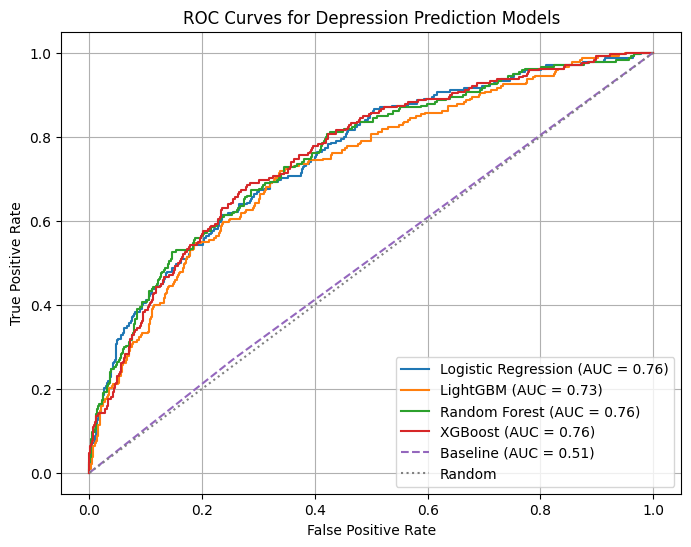

In [90]:
plt.figure(figsize=(8,6))

plt.plot(lr_fpr, lr_tpr, label=f"Logistic Regression (AUC = {lr_auc:.2f})")
plt.plot(lgbm_fpr, lgbm_tpr, label=f"LightGBM (AUC = {lgbm_auc:.2f})")
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {rf_auc:.2f})")
plt.plot(xgb_fpr, xgb_tpr, label=f"XGBoost (AUC = {xgb_auc:.2f})")

# baseline
plt.plot(base_fpr, base_tpr, linestyle='--', label=f"Baseline (AUC = {base_auc:.2f})")

# random guess line (optional but recommended)
plt.plot([0,1], [0,1], linestyle=':', color='gray', label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Depression Prediction Models")
plt.legend()
plt.grid()

plt.show()